# SECOM Dataset - Comprehensive Exploratory Data Analysis

**Project**: Semiconductor Manufacturing Yield Prediction  
**Dataset**: UCI SECOM (Semiconductor Manufacturing)  
**Goal**: Deep dive into features, patterns, and quality issues to inform feature engineering

## Table of Contents
1. [Data Loading](#1-data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Missing Value Analysis](#3-missing-value-analysis)
4. [Feature Distributions](#4-feature-distributions)
5. [Pass vs Fail Comparison](#5-pass-vs-fail-comparison)
6. [Correlation Analysis](#6-correlation-analysis)
7. [Outlier Detection](#7-outlier-detection)
8. [Feature Variance & Redundancy](#8-feature-variance-redundancy)
9. [Temporal Patterns](#9-temporal-patterns)
10. [Key Insights & Recommendations](#10-key-insights-recommendations)

## Setup

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
import warnings

# Custom modules
from src.data.data_loader import SECOMDataLoader

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

%matplotlib inline

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete!")

Setup complete!


## 1. Data Loading

In [2]:
# Initialize data loader
loader = SECOMDataLoader(data_dir="../data/raw")

# Load data
features, labels, timestamps = loader.load_data()

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Timestamps shape: {timestamps.shape}")

Features shape: (1567, 590)
Labels shape: (1567,)
Timestamps shape: (1567,)


In [3]:
# Quick peek at the data
print("First 5 rows of features (first 10 columns):")
display(features.iloc[:5, :10])

print("\nLabels distribution:")
print(labels.value_counts())
print(f"\nFailure rate: {labels.mean():.2%}")

First 5 rows of features (first 10 columns):


,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031



Labels distribution:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64

Failure rate: 6.64%


## 2. Dataset Overview

In [4]:
# Get comprehensive summary
summary = loader.get_data_summary()

print("="*80)
print("DATASET SUMMARY")
print("="*80)
print(f"Total Samples:              {summary['n_samples']:,}")
print(f"Total Features:             {summary['n_features']:,}")
print(f"\nClass Distribution:")
print(f"  Pass (Class 0):           {summary['n_pass']:,} ({summary['n_pass']/summary['n_samples']:.1%})")
print(f"  Fail (Class 1):           {summary['n_fail']:,} ({summary['n_fail']/summary['n_samples']:.1%})")
print(f"  Imbalance Ratio:          1:{summary['n_pass']/summary['n_fail']:.1f} (Pass:Fail)")
print(f"\nMissing Values:")
print(f"  Overall Missing Rate:     {summary['missing_value_rate']:.2%}")
print(f"  Features with Missing:    {summary['features_with_missing']:,} ({summary['features_with_missing']/summary['n_features']:.1%})")
print(f"  Samples with Missing:     {summary['samples_with_missing']:,} ({summary['samples_with_missing']/summary['n_samples']:.1%})")
print("="*80)

DATASET SUMMARY
Total Samples:              1,567
Total Features:             590

Class Distribution:
  Pass (Class 0):           1,463 (93.4%)
  Fail (Class 1):           104 (6.6%)
  Imbalance Ratio:          1:14.1 (Pass:Fail)

Missing Values:
  Overall Missing Rate:     4.54%
  Features with Missing:    538 (91.2%)
  Samples with Missing:     1,567 (100.0%)


In [5]:
# Basic statistics for all features
feature_stats = features.describe().T
feature_stats['missing_pct'] = (features.isna().sum() / len(features) * 100)
feature_stats['zeros_pct'] = ((features == 0).sum() / len(features) * 100)

print("Summary statistics (first 20 features):")
display(feature_stats.head(20))

Summary statistics (first 20 features):


,count,mean,std,min,25%,50%,75%,max,missing_pct,zeros_pct
Feature_0,1561.0,3014.452896,73.621787,2743.2400,2966.260000,3011.49000,3056.650000,3356.3500,0.382897,0.000000
Feature_1,1560.0,2495.850231,80.407705,2158.7500,2452.247500,2499.40500,2538.822500,2846.4400,0.446713,0.000000
Feature_2,1553.0,2200.547318,29.513152,2060.6600,2181.044400,2201.06670,2218.055500,2315.2667,0.893427,0.000000
Feature_3,1553.0,1396.376627,441.691640,0.0000,1081.875800,1285.21440,1591.223500,3715.0417,0.893427,0.063816
Feature_4,1553.0,4.197013,56.355540,0.6815,1.017700,1.31680,1.525700,1114.5366,0.893427,0.000000
Feature_5,1553.0,100.000000,0.000000,100.0000,100.000000,100.00000,100.000000,100.0000,0.893427,0.000000
Feature_6,1553.0,101.112908,6.237214,82.1311,97.920000,101.51220,104.586700,129.2522,0.893427,0.000000
Feature_7,1558.0,0.121822,0.008961,0.0000,0.121100,0.12240,0.123800,0.1286,0.574346,0.510530
Feature_8,1565.0,1.462862,0.073897,1.1910,1.411200,1.46160,1.516900,1.6564,0.127632,0.000000
Feature_9,1565.0,-0.000841,0.015116,-0.0534,-0.010800,-0.00130,0.008400,0.0749,0.127632,0.319081


## 3. Missing Value Analysis

Understanding missing value patterns is critical for this dataset.

In [6]:
# Get missing value analysis from loader
missing_analysis = loader.get_missing_value_analysis()

print("Top 30 features with most missing values:")
display(missing_analysis.head(30))

# Categorize features by missing percentage
missing_cats = {
    'No Missing': len(missing_analysis[missing_analysis['Missing_Percentage'] == 0]),
    'Low (0-10%)': len(missing_analysis[(missing_analysis['Missing_Percentage'] > 0) & 
                                         (missing_analysis['Missing_Percentage'] <= 10)]),
    'Medium (10-40%)': len(missing_analysis[(missing_analysis['Missing_Percentage'] > 10) & 
                                             (missing_analysis['Missing_Percentage'] <= 40)]),
    'High (>40%)': len(missing_analysis[missing_analysis['Missing_Percentage'] > 40])
}

print("\nFeature categorization by missing values:")
for cat, count in missing_cats.items():
    print(f"  {cat:20s}: {count:3d} features ({count/len(missing_analysis)*100:.1f}%)")

Top 30 features with most missing values:


,Feature,Missing_Count,Missing_Percentage
Feature_292,Feature_292,1429,91.193363
Feature_293,Feature_293,1429,91.193363
Feature_158,Feature_158,1429,91.193363
Feature_157,Feature_157,1429,91.193363
Feature_492,Feature_492,1341,85.577537
Feature_85,Feature_85,1341,85.577537
Feature_358,Feature_358,1341,85.577537
Feature_220,Feature_220,1341,85.577537
Feature_244,Feature_244,1018,64.964901
Feature_517,Feature_517,1018,64.964901



Feature categorization by missing values:
  No Missing          :  52 features (8.8%)
  Low (0-10%)         : 486 features (82.4%)
  Medium (10-40%)     :  20 features (3.4%)
  High (>40%)         :  32 features (5.4%)


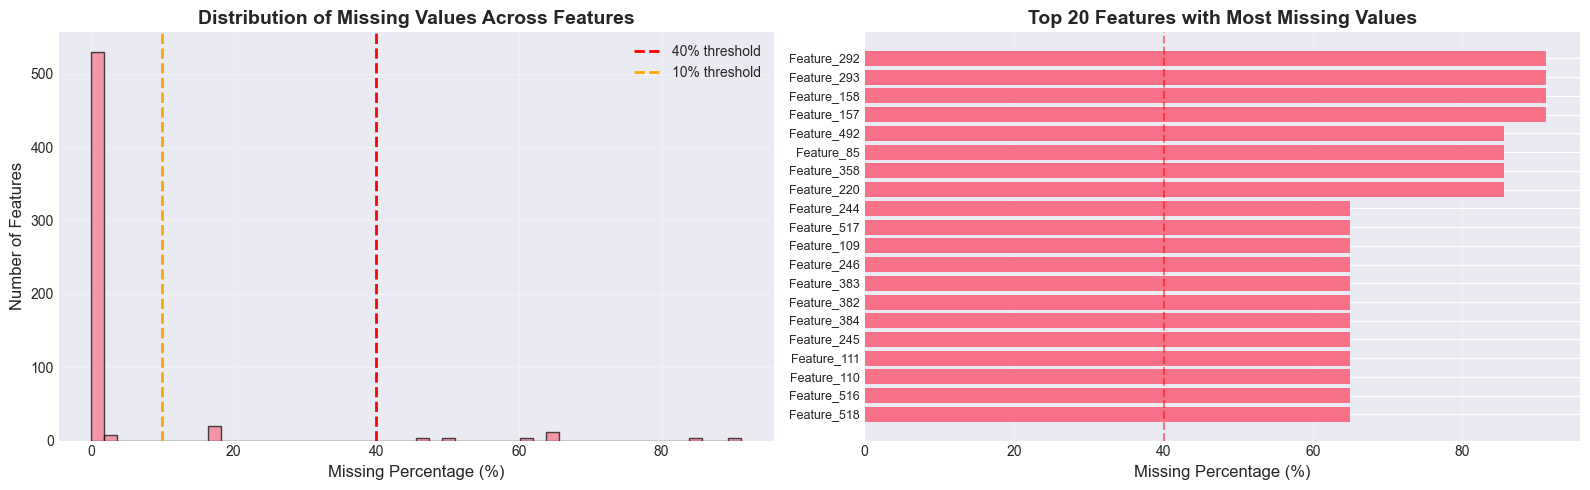

Figure saved: reports/figures/eda_01_missing_values.png


In [7]:
# Visualize missing value distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of missing percentages
axes[0].hist(missing_analysis['Missing_Percentage'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(40, color='red', linestyle='--', linewidth=2, label='40% threshold')
axes[0].axvline(10, color='orange', linestyle='--', linewidth=2, label='10% threshold')
axes[0].set_xlabel('Missing Percentage (%)', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Distribution of Missing Values Across Features', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 20 features with most missing
top_missing = missing_analysis.head(20)
axes[1].barh(range(len(top_missing)), top_missing['Missing_Percentage'])
axes[1].set_yticks(range(len(top_missing)))
axes[1].set_yticklabels(top_missing['Feature'], fontsize=9)
axes[1].set_xlabel('Missing Percentage (%)', fontsize=12)
axes[1].set_title('Top 20 Features with Most Missing Values', fontsize=14, fontweight='bold')
axes[1].axvline(40, color='red', linestyle='--', alpha=0.5)
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../reports/figures/eda_01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: reports/figures/eda_01_missing_values.png")

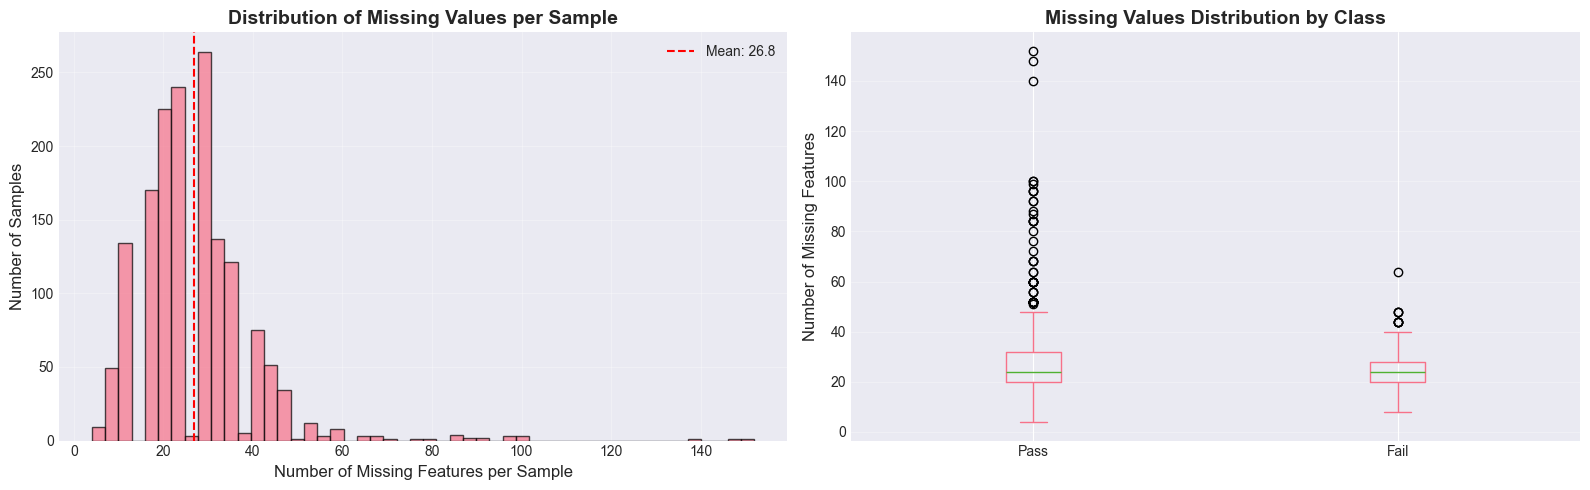


Missing values per sample statistics:
  Pass samples - Mean: 26.9, Median: 24.0
  Fail samples - Mean: 25.5, Median: 24.0

Mann-Whitney U test for missing values difference:
  p-value: 0.3477 (Not significant)


In [8]:
# Missing value patterns per sample
missing_per_sample = features.isna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of missing values per sample
axes[0].hist(missing_per_sample, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Missing Features per Sample', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Distribution of Missing Values per Sample', fontsize=14, fontweight='bold')
axes[0].axvline(missing_per_sample.mean(), color='red', linestyle='--', 
                label=f'Mean: {missing_per_sample.mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Missing patterns by class
missing_by_class = pd.DataFrame({
    'Pass': missing_per_sample[labels == 0],
    'Fail': missing_per_sample[labels == 1]
})

missing_by_class.plot(kind='box', ax=axes[1])
axes[1].set_ylabel('Number of Missing Features', fontsize=12)
axes[1].set_title('Missing Values Distribution by Class', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/figures/eda_02_missing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMissing values per sample statistics:")
print(f"  Pass samples - Mean: {missing_per_sample[labels==0].mean():.1f}, Median: {missing_per_sample[labels==0].median():.1f}")
print(f"  Fail samples - Mean: {missing_per_sample[labels==1].mean():.1f}, Median: {missing_per_sample[labels==1].median():.1f}")

# Statistical test
stat, pval = stats.mannwhitneyu(missing_per_sample[labels==0], missing_per_sample[labels==1])
print(f"\nMann-Whitney U test for missing values difference:")
print(f"  p-value: {pval:.4f} {'(Significant)' if pval < 0.05 else '(Not significant)'}")

## 4. Feature Distributions

Analyze the distribution characteristics of features.

In [9]:
# Identify features with low missing rates for detailed analysis
good_features = missing_analysis[missing_analysis['Missing_Percentage'] < 10]['Feature'].tolist()[:50]
print(f"Analyzing {len(good_features)} features with <10% missing values")

# Calculate skewness and kurtosis for these features
distribution_stats = pd.DataFrame({
    'Feature': good_features,
    'Skewness': [features[f].skew() for f in good_features],
    'Kurtosis': [features[f].kurtosis() for f in good_features],
    'Mean': [features[f].mean() for f in good_features],
    'Std': [features[f].std() for f in good_features],
    'CV': [features[f].std() / features[f].mean() if features[f].mean() != 0 else np.nan for f in good_features]
})

print("\nDistribution statistics (first 20 features):")
display(distribution_stats.head(20))

Analyzing 50 features with <10% missing values

Distribution statistics (first 20 features):


,Feature,Skewness,Kurtosis,Mean,Std,CV
0,Feature_363,0.983751,1.273102,333.319601,138.801928,0.416423
1,Feature_362,7.943454,106.333113,0.018383,0.021644,1.177401
2,Feature_497,1.065395,1.719567,11.821030,4.956647,0.419308
3,Feature_90,0.341646,1.215154,8827.536865,396.313662,0.044895
4,Feature_89,18.341933,422.940119,0.188703,0.052373,0.277541
5,Feature_225,1.073636,1.770174,1041.056588,433.170076,0.416087
6,Feature_224,8.290627,119.122975,0.059370,0.071211,1.199439
7,Feature_496,3.226793,13.986357,29.865896,24.621586,0.824405
8,Feature_450,0.000000,0.000000,0.000000,0.000000,NaN
9,Feature_41,12.212706,175.933165,3.353066,2.360425,0.703960


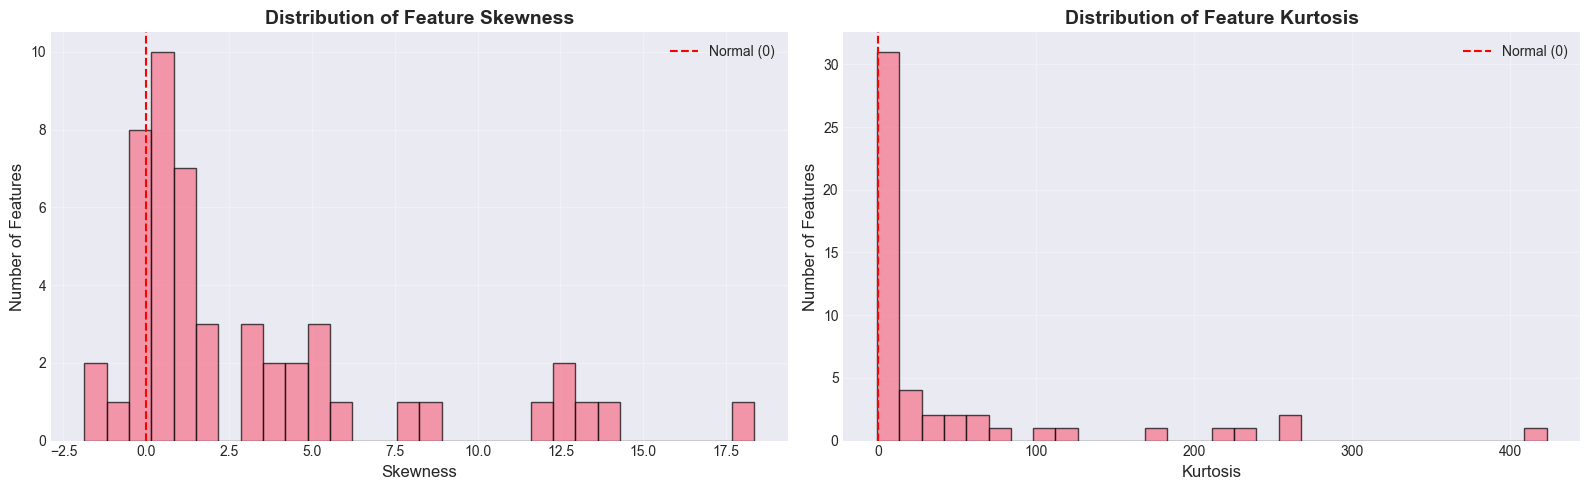


19 features have |skewness| > 2 (may need transformation)


In [10]:
# Visualize distribution characteristics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Skewness distribution
axes[0].hist(distribution_stats['Skewness'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', label='Normal (0)')
axes[0].set_xlabel('Skewness', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Distribution of Feature Skewness', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Kurtosis distribution
axes[1].hist(distribution_stats['Kurtosis'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', label='Normal (0)')
axes[1].set_xlabel('Kurtosis', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('Distribution of Feature Kurtosis', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_03_distribution_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify highly skewed features
highly_skewed = distribution_stats[abs(distribution_stats['Skewness']) > 2]
print(f"\n{len(highly_skewed)} features have |skewness| > 2 (may need transformation)")

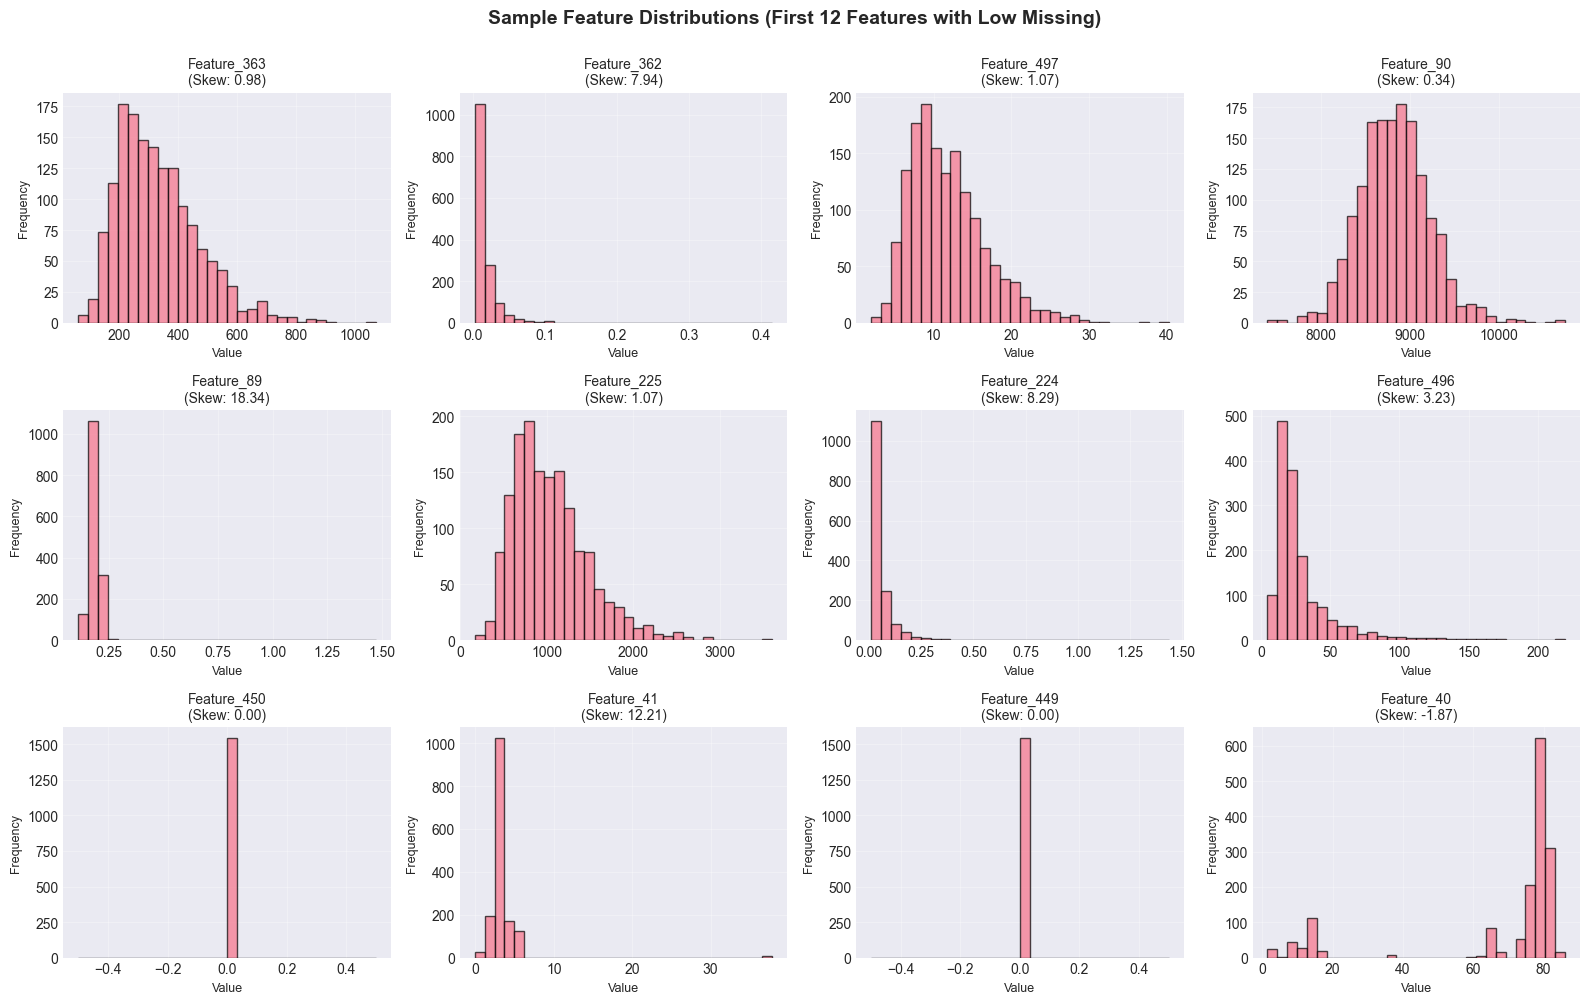

In [11]:
# Sample feature distributions
sample_features = good_features[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(sample_features):
    data = features[feature].dropna()
    axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature}\n(Skew: {data.skew():.2f})', fontsize=10)
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Sample Feature Distributions (First 12 Features with Low Missing)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../reports/figures/eda_04_sample_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Pass vs Fail Comparison

Compare feature distributions between pass and fail cases.

In [12]:
# Statistical comparison of features between pass and fail
comparison_results = []

for feature in good_features:
    pass_data = features.loc[labels == 0, feature].dropna()
    fail_data = features.loc[labels == 1, feature].dropna()
    
    # Skip if too few samples
    if len(pass_data) < 10 or len(fail_data) < 10:
        continue
    
    # Mann-Whitney U test (non-parametric)
    stat, pval = stats.mannwhitneyu(pass_data, fail_data, alternative='two-sided')
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((pass_data.std()**2 + fail_data.std()**2) / 2)
    cohens_d = (pass_data.mean() - fail_data.mean()) / pooled_std if pooled_std > 0 else 0
    
    comparison_results.append({
        'Feature': feature,
        'Pass_Mean': pass_data.mean(),
        'Fail_Mean': fail_data.mean(),
        'Mean_Diff': fail_data.mean() - pass_data.mean(),
        'P_Value': pval,
        'Cohens_D': cohens_d,
        'Significant': pval < 0.05
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('P_Value')

print(f"Statistical comparison completed for {len(comparison_df)} features")
print(f"\nSignificant features (p < 0.05): {comparison_df['Significant'].sum()}")
print("\nTop 20 most significant features:")
display(comparison_df.head(20))

Statistical comparison completed for 50 features

Significant features (p < 0.05): 9

Top 20 most significant features:


,Feature,Pass_Mean,Fail_Mean,Mean_Diff,P_Value,Cohens_D,Significant
16,Feature_348,0.024291,0.030448,0.006157,0.001602,-0.333026,True
11,Feature_40,68.239842,63.270606,-4.969236,0.001903,0.196829,True
41,Feature_79,0.002979,0.010089,0.007110,0.003928,-0.295128,True
45,Feature_210,0.087707,0.104906,0.017199,0.012579,-0.302343,True
42,Feature_78,-0.013083,-0.021388,-0.008305,0.023132,0.171597,True
13,Feature_351,0.027300,0.031519,0.004219,0.025861,-0.160608,True
4,Feature_89,0.188270,0.194647,0.006377,0.026156,-0.069894,True
3,Feature_90,8833.289517,8748.619420,-84.670097,0.032049,0.234943,True
39,Feature_76,-0.028893,-0.036268,-0.007375,0.032838,0.217686,True
22,Feature_488,355.759291,309.130808,-46.628483,0.063374,0.181170,False


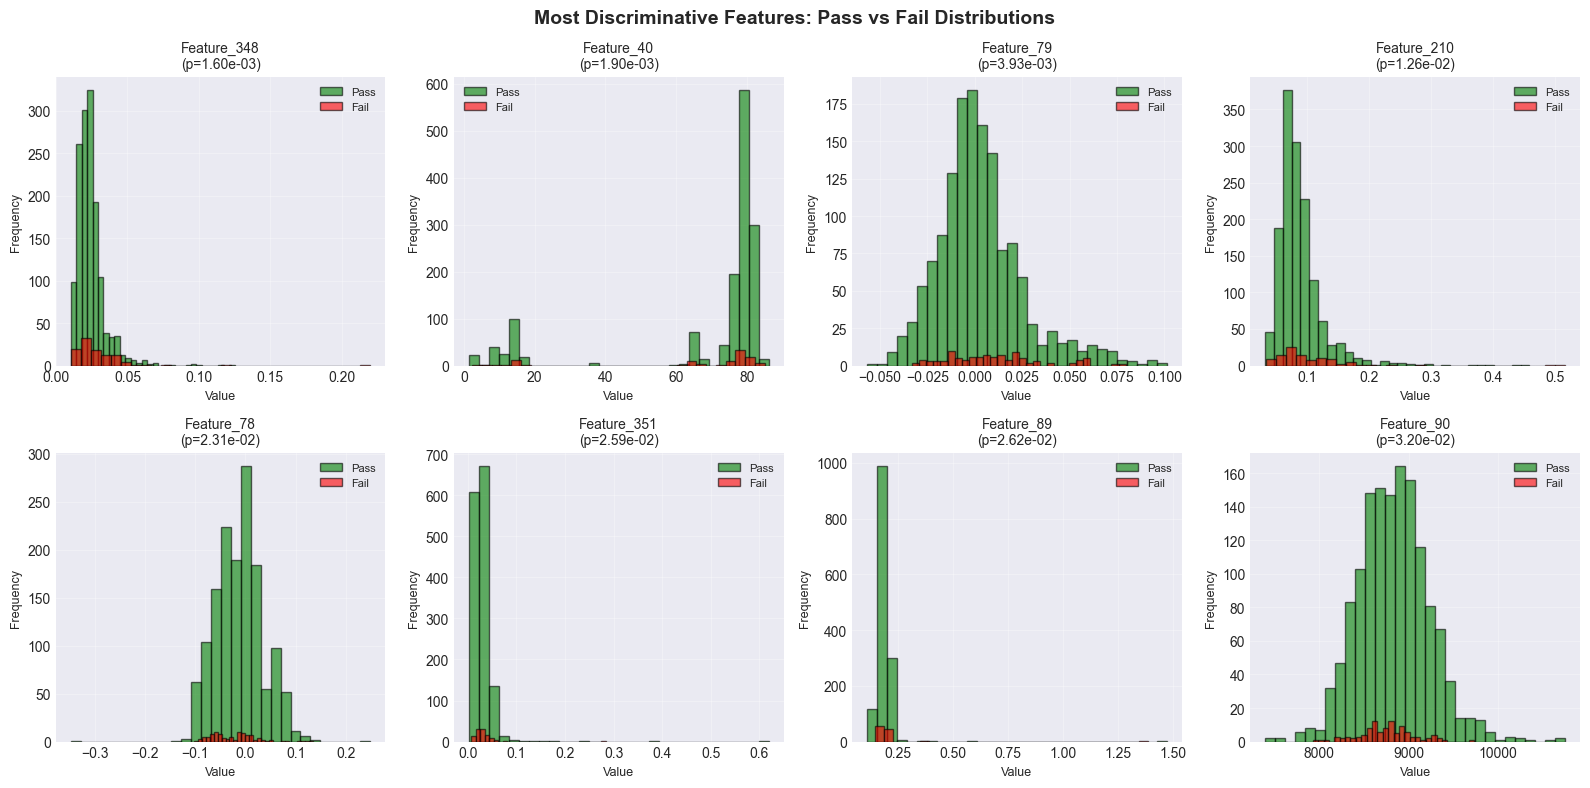

In [13]:
# Visualize most discriminative features
top_discriminative = comparison_df.head(8)['Feature'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(top_discriminative):
    pass_data = features.loc[labels == 0, feature].dropna()
    fail_data = features.loc[labels == 1, feature].dropna()
    
    axes[i].hist(pass_data, bins=30, alpha=0.6, label='Pass', color='green', edgecolor='black')
    axes[i].hist(fail_data, bins=30, alpha=0.6, label='Fail', color='red', edgecolor='black')
    axes[i].set_title(f'{feature}\n(p={comparison_df[comparison_df["Feature"]==feature]["P_Value"].values[0]:.2e})', 
                      fontsize=10)
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('Most Discriminative Features: Pass vs Fail Distributions', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda_05_pass_vs_fail.png', dpi=150, bbox_inches='tight')
plt.show()

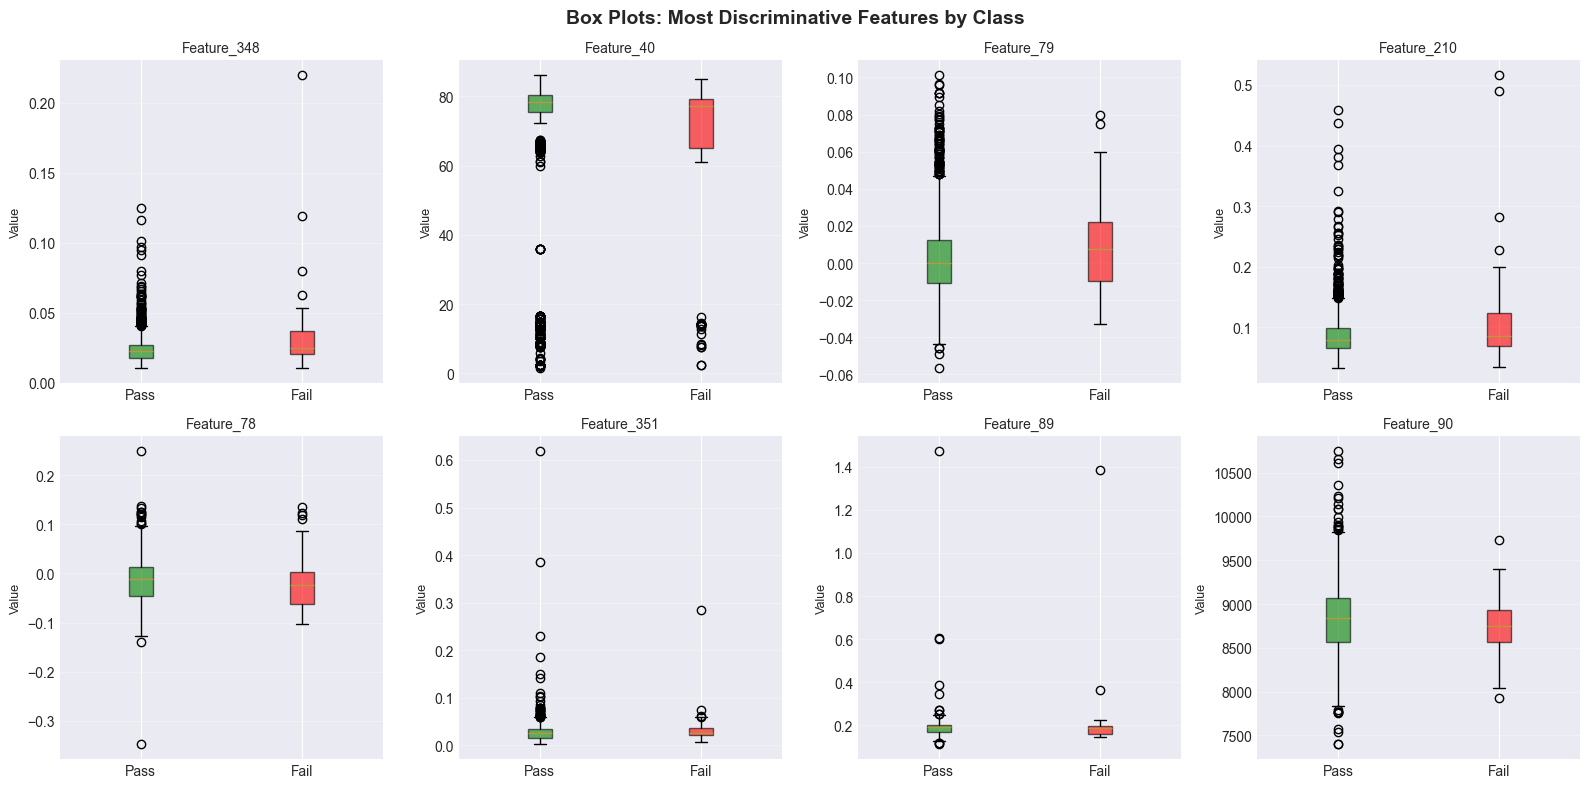

In [14]:
# Box plots for top discriminative features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(top_discriminative):
    data_to_plot = [features.loc[labels == 0, feature].dropna(),
                    features.loc[labels == 1, feature].dropna()]
    
    bp = axes[i].boxplot(data_to_plot, labels=['Pass', 'Fail'], patch_artist=True)
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][1].set_facecolor('red')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_alpha(0.6)
    
    axes[i].set_title(f'{feature}', fontsize=10)
    axes[i].set_ylabel('Value', fontsize=9)
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('Box Plots: Most Discriminative Features by Class', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda_06_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

Examine correlations between features and with the target.

In [15]:
# Select features with low missing for correlation analysis
low_missing_features = missing_analysis[missing_analysis['Missing_Percentage'] < 20]['Feature'].tolist()[:100]
print(f"Analyzing correlations for {len(low_missing_features)} features with <20% missing")

# Calculate correlation with target
target_correlations = []
for feature in low_missing_features:
    # Use Spearman correlation (robust to outliers and non-linear)
    valid_mask = ~features[feature].isna()
    if valid_mask.sum() > 100:
        corr, pval = stats.spearmanr(features.loc[valid_mask, feature], labels[valid_mask])
        target_correlations.append({
            'Feature': feature,
            'Correlation': corr,
            'Abs_Correlation': abs(corr),
            'P_Value': pval
        })

target_corr_df = pd.DataFrame(target_correlations)
target_corr_df = target_corr_df.sort_values('Abs_Correlation', ascending=False)

print("\nTop 20 features most correlated with target:")
display(target_corr_df.head(20))

Analyzing correlations for 100 features with <20% missing

Top 20 features most correlated with target:


,Feature,Correlation,Abs_Correlation,P_Value
97,Feature_290,0.082377,0.082377,0.001140
36,Feature_348,0.080360,0.080360,0.001582
31,Feature_40,-0.079074,0.079074,0.001881
61,Feature_79,0.073444,0.073444,0.003895
98,Feature_155,0.069141,0.069141,0.006347
95,Feature_428,0.068723,0.068723,0.006673
65,Feature_210,0.063552,0.063552,0.012528
62,Feature_78,-0.057842,0.057842,0.023077
24,Feature_89,-0.057138,0.057138,0.026100
33,Feature_351,0.056748,0.056748,0.025806


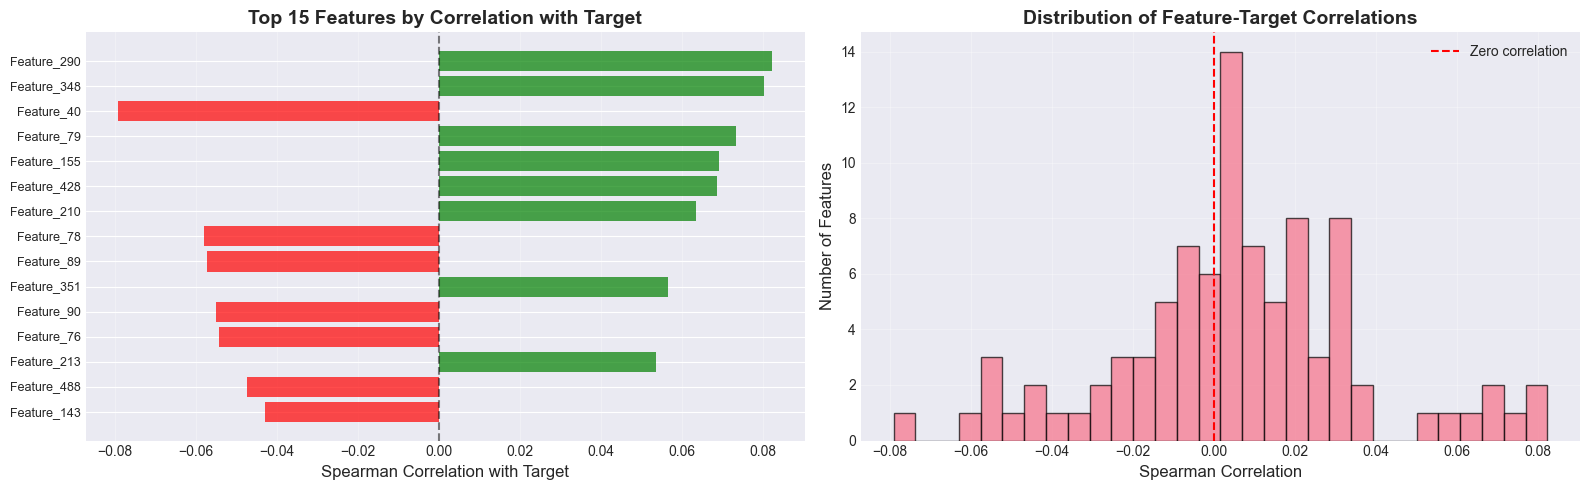

In [16]:
# Visualize target correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top positive and negative correlations
top_corr = target_corr_df.head(15)
colors = ['red' if x < 0 else 'green' for x in top_corr['Correlation']]

axes[0].barh(range(len(top_corr)), top_corr['Correlation'], color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr['Feature'], fontsize=9)
axes[0].set_xlabel('Spearman Correlation with Target', fontsize=12)
axes[0].set_title('Top 15 Features by Correlation with Target', fontsize=14, fontweight='bold')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# Distribution of correlations
axes[1].hist(target_corr_df['Correlation'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', label='Zero correlation')
axes[1].set_xlabel('Spearman Correlation', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('Distribution of Feature-Target Correlations', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_07_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

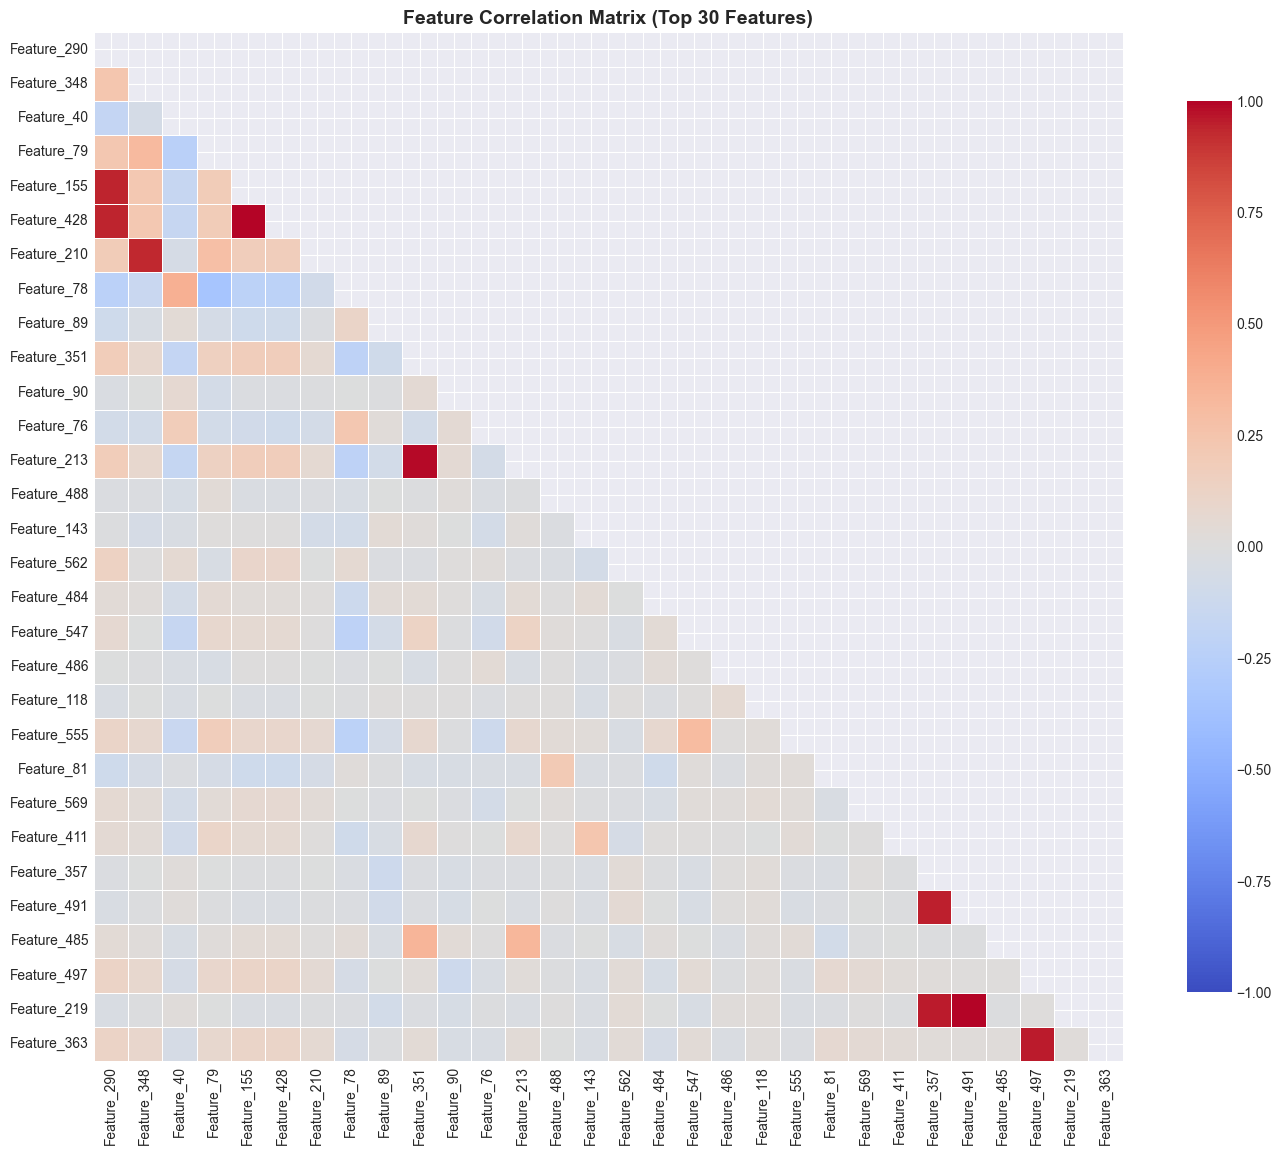


Found 9 highly correlated feature pairs (|corr| > 0.8):


,Feature1,Feature2,Correlation
0,Feature_290,Feature_155,0.944613
1,Feature_290,Feature_428,0.945052
2,Feature_348,Feature_210,0.932464
3,Feature_155,Feature_428,0.999524
4,Feature_351,Feature_213,0.989367
5,Feature_357,Feature_491,0.952890
6,Feature_357,Feature_219,0.960553
7,Feature_491,Feature_219,0.994189
8,Feature_497,Feature_363,0.960735


In [17]:
# Feature-feature correlation (for top features)
top_features_for_corr = target_corr_df.head(30)['Feature'].tolist()
feature_subset = features[top_features_for_corr].copy()

# Fill missing with median for correlation calculation
for col in feature_subset.columns:
    feature_subset[col].fillna(feature_subset[col].median(), inplace=True)

# Calculate correlation matrix
corr_matrix = feature_subset.corr(method='spearman')

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix (Top 30 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda_08_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated feature pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\nFound {len(high_corr_pairs)} highly correlated feature pairs (|corr| > 0.8):")
    display(pd.DataFrame(high_corr_pairs))
else:
    print("\nNo highly correlated feature pairs found (|corr| > 0.8)")

## 7. Outlier Detection

Identify and analyze outliers in the dataset.

In [18]:
# Detect outliers using IQR method
outlier_counts = []

for feature in low_missing_features[:50]:
    data = features[feature].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((data < lower_bound) | (data > upper_bound)).sum()
    outlier_pct = outliers / len(data) * 100
    
    outlier_counts.append({
        'Feature': feature,
        'Outlier_Count': outliers,
        'Outlier_Percentage': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_counts)
outlier_df = outlier_df.sort_values('Outlier_Percentage', ascending=False)

print("Top 20 features with most outliers:")
display(outlier_df.head(20))

Top 20 features with most outliers:


,Feature,Outlier_Count,Outlier_Percentage
31,Feature_40,235,15.230071
21,Feature_362,84,5.540897
26,Feature_224,81,5.343008
27,Feature_496,66,4.353562
43,Feature_214,37,2.397926
12,Feature_552,27,2.065800
7,Feature_569,26,2.009274
19,Feature_549,26,1.989288
29,Feature_41,29,1.879456
36,Feature_348,28,1.814647


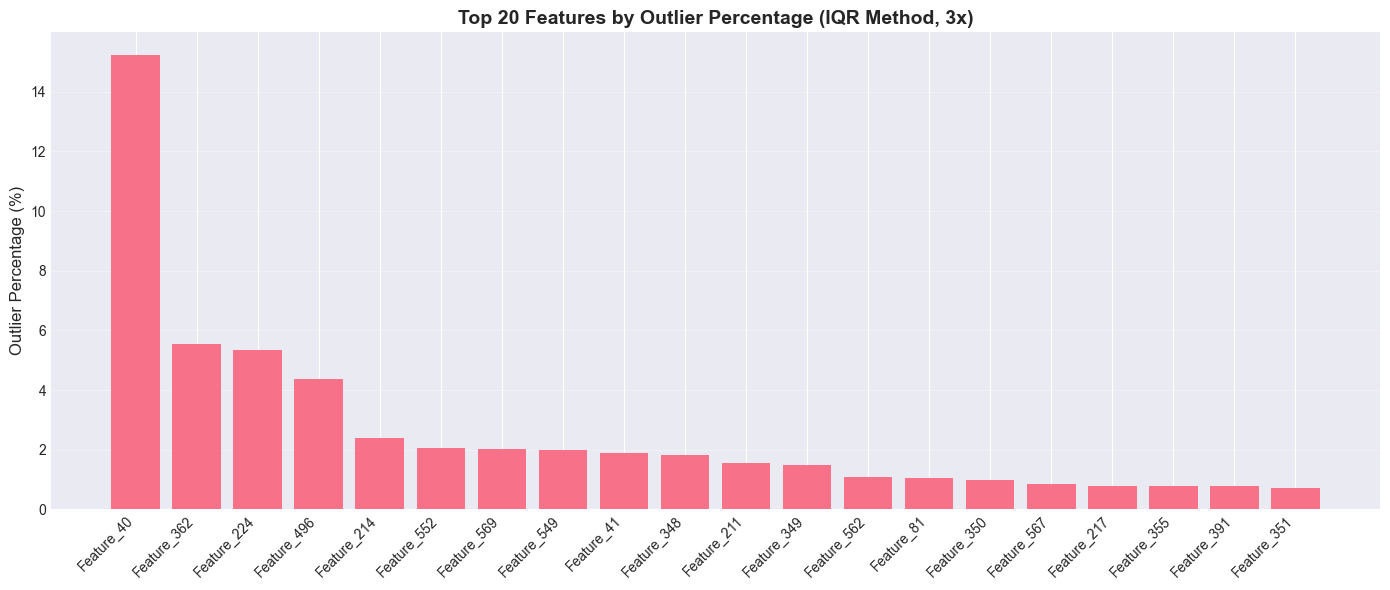

In [19]:
# Visualize outliers
fig, ax = plt.subplots(figsize=(14, 6))

top_outlier_features = outlier_df.head(20)
ax.bar(range(len(top_outlier_features)), top_outlier_features['Outlier_Percentage'])
ax.set_xticks(range(len(top_outlier_features)))
ax.set_xticklabels(top_outlier_features['Feature'], rotation=45, ha='right')
ax.set_ylabel('Outlier Percentage (%)', fontsize=12)
ax.set_title('Top 20 Features by Outlier Percentage (IQR Method, 3x)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/figures/eda_09_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Variance & Redundancy

Identify low-variance and potentially redundant features.

In [20]:
# Calculate variance statistics
variance_stats = []

for feature in features.columns:
    data = features[feature].dropna()
    if len(data) > 0:
        variance_stats.append({
            'Feature': feature,
            'Variance': data.var(),
            'Std': data.std(),
            'Unique_Values': data.nunique(),
            'Zero_Variance': data.var() < 1e-10
        })

variance_df = pd.DataFrame(variance_stats)
variance_df = variance_df.sort_values('Variance', ascending=True)

print(f"Features with near-zero variance: {variance_df['Zero_Variance'].sum()}")
print("\nBottom 20 features by variance:")
display(variance_df.head(20))

Features with near-zero variance: 116

Bottom 20 features by variance:


,Feature,Variance,Std,Unique_Values,Zero_Variance
505,Feature_505,0.0,0.0,1,True
506,Feature_506,0.0,0.0,1,True
507,Feature_507,0.0,0.0,1,True
508,Feature_508,0.0,0.0,1,True
325,Feature_325,0.0,0.0,1,True
509,Feature_509,0.0,0.0,1,True
284,Feature_284,0.0,0.0,1,True
257,Feature_257,0.0,0.0,1,True
537,Feature_537,0.0,0.0,1,True
536,Feature_536,0.0,0.0,1,True


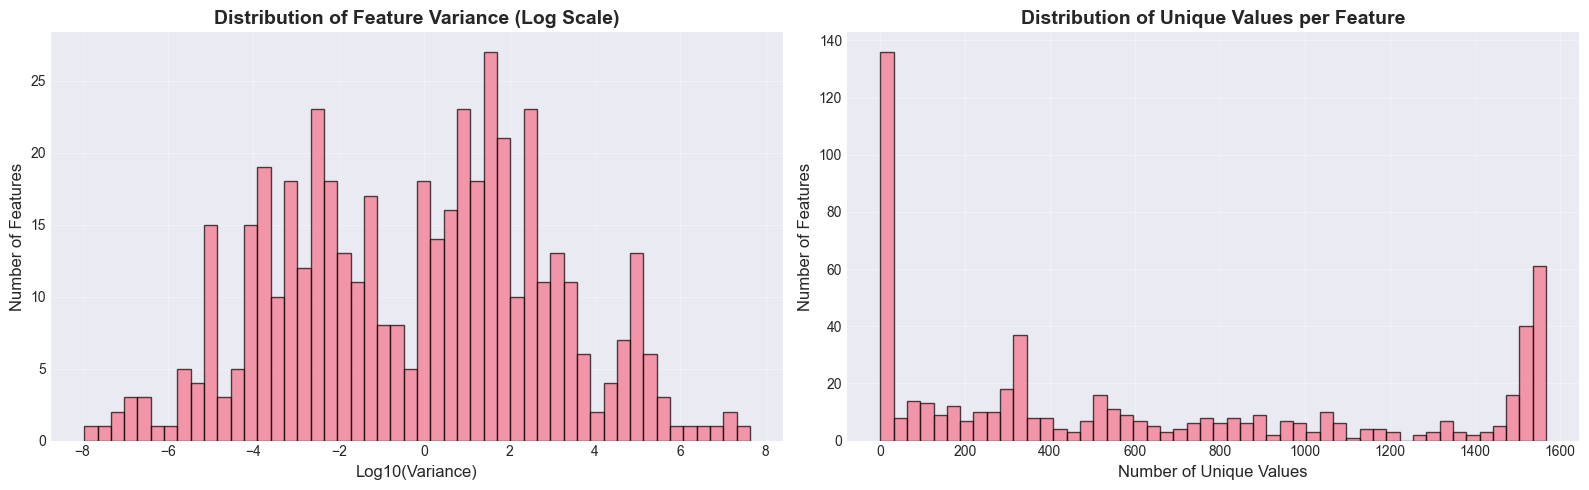

In [21]:
# Visualize variance distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Variance distribution (log scale)
variance_values = variance_df[variance_df['Variance'] > 0]['Variance']
axes[0].hist(np.log10(variance_values), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Log10(Variance)', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Distribution of Feature Variance (Log Scale)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Unique values distribution
axes[1].hist(variance_df['Unique_Values'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Unique Values', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('Distribution of Unique Values per Feature', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_10_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Temporal Patterns

Analyze temporal patterns in the data using timestamps.

In [22]:
# Analyze temporal patterns
temporal_df = pd.DataFrame({
    'Timestamp': timestamps,
    'Label': labels
})

# Sort by timestamp
temporal_df = temporal_df.sort_values('Timestamp').reset_index(drop=True)
temporal_df['Sequential_Index'] = range(len(temporal_df))

print(f"Timestamp range: {timestamps.min()} to {timestamps.max()}")
print(f"Unique timestamps: {timestamps.nunique()}")
print(f"Samples per timestamp (avg): {len(timestamps) / timestamps.nunique():.2f}")

Timestamp range: 2008-01-08 02:02:00 to 2008-12-10 18:47:00
Unique timestamps: 1534
Samples per timestamp (avg): 1.02


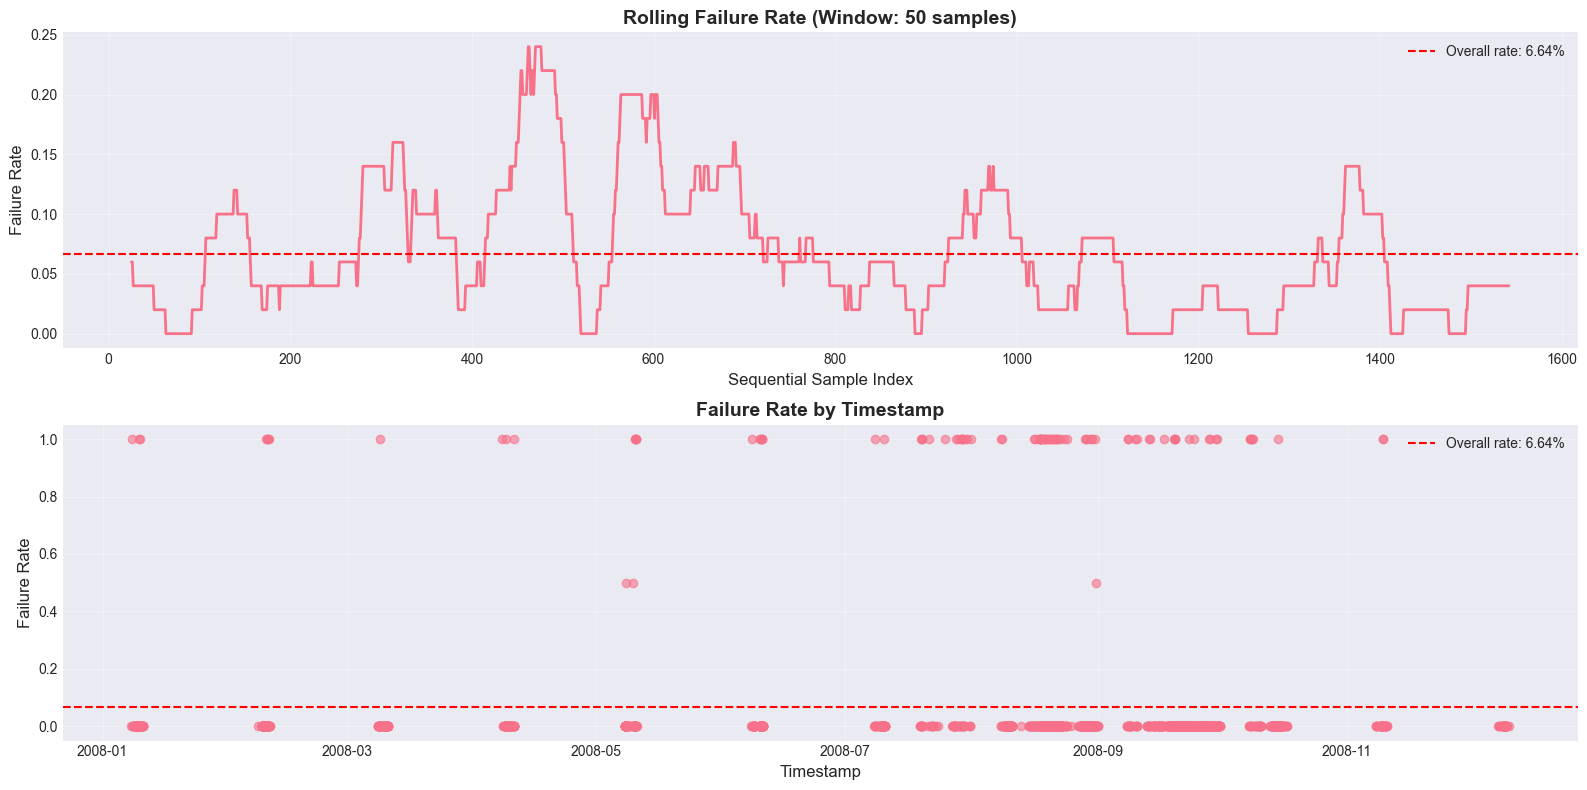

In [23]:
# Visualize failure rate over time
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Failure rate over sequential samples
window_size = 50
rolling_failure_rate = temporal_df['Label'].rolling(window=window_size, center=True).mean()

axes[0].plot(temporal_df['Sequential_Index'], rolling_failure_rate, linewidth=2)
axes[0].axhline(labels.mean(), color='red', linestyle='--', label=f'Overall rate: {labels.mean():.2%}')
axes[0].set_xlabel('Sequential Sample Index', fontsize=12)
axes[0].set_ylabel('Failure Rate', fontsize=12)
axes[0].set_title(f'Rolling Failure Rate (Window: {window_size} samples)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Failures by timestamp
failures_by_time = temporal_df.groupby('Timestamp')['Label'].agg(['sum', 'count', 'mean'])
failures_by_time.columns = ['Failures', 'Total', 'Failure_Rate']

axes[1].scatter(failures_by_time.index, failures_by_time['Failure_Rate'], alpha=0.6)
axes[1].axhline(labels.mean(), color='red', linestyle='--', label=f'Overall rate: {labels.mean():.2%}')
axes[1].set_xlabel('Timestamp', fontsize=12)
axes[1].set_ylabel('Failure Rate', fontsize=12)
axes[1].set_title('Failure Rate by Timestamp', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_11_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Key Insights & Recommendations

Summary of findings and actionable recommendations for feature engineering.

In [24]:
# Compile key statistics for recommendations
high_missing_features = missing_analysis[missing_analysis['Missing_Percentage'] > 40]
low_variance_features = variance_df[variance_df['Zero_Variance'] == True]
significant_features = comparison_df[comparison_df['Significant'] == True] if len(comparison_df) > 0 else pd.DataFrame()
high_target_corr = target_corr_df[target_corr_df['Abs_Correlation'] > 0.1] if len(target_corr_df) > 0 else pd.DataFrame()

print("="*80)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("="*80)

print("\n1. MISSING VALUES")
print("-" * 80)
print(f"   • {len(high_missing_features)} features have >40% missing values")
print(f"   • Recommend: REMOVE these features (too sparse for reliable imputation)")
print(f"   • {len(missing_analysis[(missing_analysis['Missing_Percentage'] > 10) & (missing_analysis['Missing_Percentage'] <= 40)])} features have 10-40% missing")
print(f"   • Recommend: Use KNN or iterative imputation for these features")
print(f"   • {len(missing_analysis[missing_analysis['Missing_Percentage'] <= 10])} features have <10% missing")
print(f"   • Recommend: Simple median/mean imputation acceptable")

print("\n2. CLASS IMBALANCE")
print("-" * 80)
print(f"   • Imbalance ratio: 1:{summary['n_pass']/summary['n_fail']:.1f} (Pass:Fail)")
print(f"   • Only {summary['n_fail']} failure samples out of {summary['n_samples']} total")
print(f"   • Recommend: Apply SMOTE or ADASYN for oversampling minority class")
print(f"   • Recommend: Use class_weight='balanced' in models")
print(f"   • Recommend: Stratified cross-validation (5-fold minimum)")
print(f"   • Recommend: Focus on Precision-Recall, F1, ROC-AUC (not accuracy)")

print("\n3. FEATURE SELECTION")
print("-" * 80)
print(f"   • {len(significant_features)} features show significant difference between Pass/Fail")
print(f"   • {len(high_target_corr)} features have |correlation| > 0.1 with target")
print(f"   • {len(low_variance_features)} features have near-zero variance")
print(f"   • Recommend: Remove zero-variance features")
print(f"   • Recommend: Use SelectKBest, RFE, or LASSO for feature selection")
print(f"   • Recommend: Try PCA for dimensionality reduction (preserve 95% variance)")

print("\n4. DATA TRANSFORMATIONS")
print("-" * 80)
if len(distribution_stats) > 0:
    highly_skewed_count = len(distribution_stats[abs(distribution_stats['Skewness']) > 2])
    print(f"   • {highly_skewed_count} features have |skewness| > 2")
    print(f"   • Recommend: Apply log/sqrt transformation to highly skewed features")
print(f"   • Recommend: Standardize features (StandardScaler) for distance-based models")
print(f"   • Recommend: Consider robust scaling for features with outliers")

print("\n5. FEATURE ENGINEERING IDEAS")
print("-" * 80)
print(f"   • Create polynomial features from top discriminative features")
print(f"   • Create interaction terms between highly correlated features")
print(f"   • Bin continuous features (especially for tree-based models)")
print(f"   • Create aggregate features (mean/std of related sensor groups)")
print(f"   • Create missing value indicators for features with 10-40% missing")

print("\n6. MODELING RECOMMENDATIONS")
print("-" * 80)
print(f"   • Baseline: Logistic Regression with class weights")
print(f"   • Tree-based: Random Forest, XGBoost, LightGBM (handle imbalance well)")
print(f"   • Ensemble: Stack multiple models for better performance")
print(f"   • Anomaly detection: Isolation Forest, One-Class SVM (for failure detection)")
print(f"   • Deep learning: Autoencoder for anomaly detection, Neural Network with SMOTE")

print("\n7. VALIDATION STRATEGY")
print("-" * 80)
print(f"   • Use stratified 5-fold cross-validation")
print(f"   • Reserve 20% for final test set (already done)")
print(f"   • Use 10% for validation during hyperparameter tuning (already done)")
print(f"   • Consider time-based split if temporal ordering is important")

print("\n" + "="*80)
print("NEXT STEPS")
print("="*80)
print("1. Create feature engineering pipeline (notebooks/02_feature_engineering.ipynb)")
print("2. Implement preprocessing steps:")
print("   - Remove features with >40% missing")
print("   - Impute remaining missing values")
print("   - Apply transformations to skewed features")
print("   - Scale features appropriately")
print("3. Create and save engineered datasets for modeling")
print("4. Begin baseline modeling (notebooks/03_baseline_models.ipynb)")
print("="*80)

KEY INSIGHTS & RECOMMENDATIONS

1. MISSING VALUES
--------------------------------------------------------------------------------
   • 32 features have >40% missing values
   • Recommend: REMOVE these features (too sparse for reliable imputation)
   • 20 features have 10-40% missing
   • Recommend: Use KNN or iterative imputation for these features
   • 538 features have <10% missing
   • Recommend: Simple median/mean imputation acceptable

2. CLASS IMBALANCE
--------------------------------------------------------------------------------
   • Imbalance ratio: 1:14.1 (Pass:Fail)
   • Only 104 failure samples out of 1567 total
   • Recommend: Apply SMOTE or ADASYN for oversampling minority class
   • Recommend: Use class_weight='balanced' in models
   • Recommend: Stratified cross-validation (5-fold minimum)
   • Recommend: Focus on Precision-Recall, F1, ROC-AUC (not accuracy)

3. FEATURE SELECTION
--------------------------------------------------------------------------------
   • 9 

In [25]:
# Save key feature lists for next phase
recommendations = {
    'features_to_remove': high_missing_features['Feature'].tolist() + low_variance_features['Feature'].tolist(),
    'top_discriminative_features': comparison_df.head(20)['Feature'].tolist() if len(comparison_df) > 0 else [],
    'high_correlation_features': target_corr_df.head(20)['Feature'].tolist() if len(target_corr_df) > 0 else [],
    'features_need_transformation': distribution_stats[abs(distribution_stats['Skewness']) > 2]['Feature'].tolist() if len(distribution_stats) > 0 else []
}

# Save to file
import json
with open('../reports/eda_recommendations.json', 'w') as f:
    json.dump(recommendations, f, indent=2)

print("Recommendations saved to: reports/eda_recommendations.json")
print(f"\nFeatures to remove: {len(recommendations['features_to_remove'])}")
print(f"Top discriminative features: {len(recommendations['top_discriminative_features'])}")
print(f"High correlation features: {len(recommendations['high_correlation_features'])}")
print(f"Features needing transformation: {len(recommendations['features_need_transformation'])}")

Recommendations saved to: reports/eda_recommendations.json

Features to remove: 148
Top discriminative features: 20
High correlation features: 20
Features needing transformation: 19


## Summary

This EDA has revealed:

1. **Severe class imbalance** (1:14 ratio) requiring SMOTE/class weights
2. **High missing value rates** in many features, with clear removal and imputation strategies
3. **Discriminative features** that show significant differences between pass/fail cases
4. **Feature redundancy** opportunities for dimensionality reduction
5. **Distribution characteristics** informing transformation needs

All visualizations have been saved to `reports/figures/` and recommendations to `reports/eda_recommendations.json`.

**Next**: Proceed to Feature Engineering phase using these insights.